In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np

# PART - I

## 1. Rolling Line Plot (faang.csv)

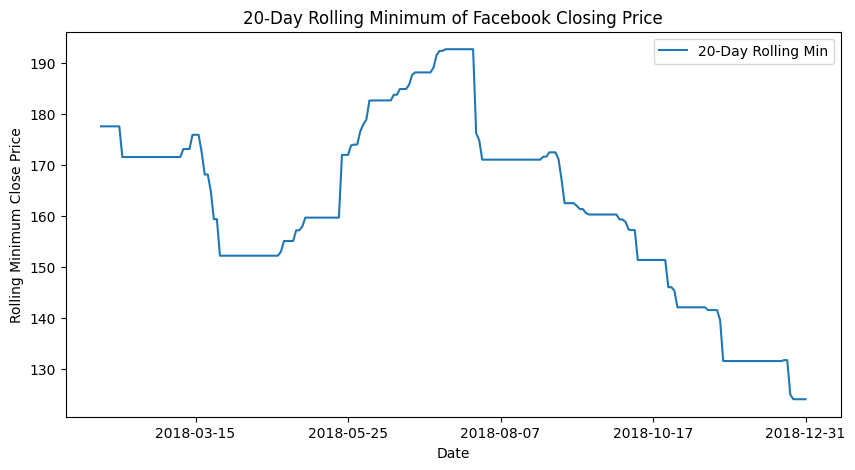

In [2]:
# Load dataset faang.csv
faang_df = pd.read_csv("CSV_Files/faang.csv")

# Set date as index
faang_df.set_index("date", inplace=True)

# Filter only Facebook data
fb = faang_df[faang_df["ticker"] == 'FB']

# Calculate rolling 20-day minimum of closing price
rolling_min = fb['close'].rolling(window=20).min()

# Plot using pandas plot() method
rolling_min.plot(figsize=(10,5))

plt.title("20-Day Rolling Minimum of Facebook Closing Price")
plt.xlabel("Date")
plt.ylabel("Rolling Minimum Close Price")
plt.legend(["20-Day Rolling Min"])

plt.show()


Here,

**What was done :** Filtered Facebook data and calculated the rolling 20-day minimum of the closing price.

**Why :** rolling(20) was used to compute the minimum closing price within every 20-day window.

**Interpretation :** The graph shows that the rolling minimum increases until mid-2018, indicating an upward trend. After July, it declines steadily, showing a downward trend in the stock price toward the end of the year.


## 2.  Histogram + KDE (faang.csv)

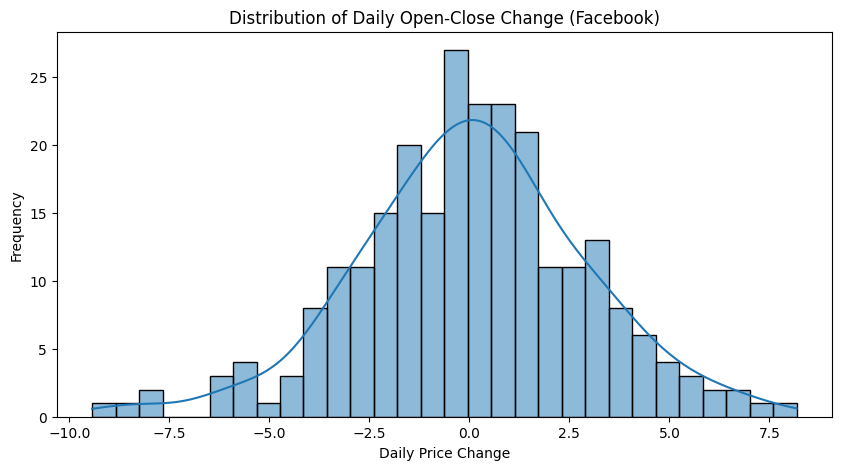

In [3]:
# Calculate daily change (close - open)
fb['daily_change'] = fb['close'] - fb['open']

# Plot histogram and KDE on same figure
plt.figure(figsize=(10,5))

sns.histplot(fb['daily_change'], bins=30, kde=True)

plt.title("Distribution of Daily Open-Close Change (Facebook)")
plt.xlabel("Daily Price Change")
plt.ylabel("Frequency")

plt.show()

Here,

**What was done :** The daily price change for Facebook was calculated by subtracting the opening price from the closing price.

**Why :** Subtracting open from close shows how much the stock price changed during the trading day.
A histogram shows how frequently different price changes occur.
A KDE plot provides a smooth curve that represents the distribution of the data.

**Interpretation :** The plot shows how Facebook's daily price changes are distributed.


## 3.  Box Plots by magType (earthquakes.csv)

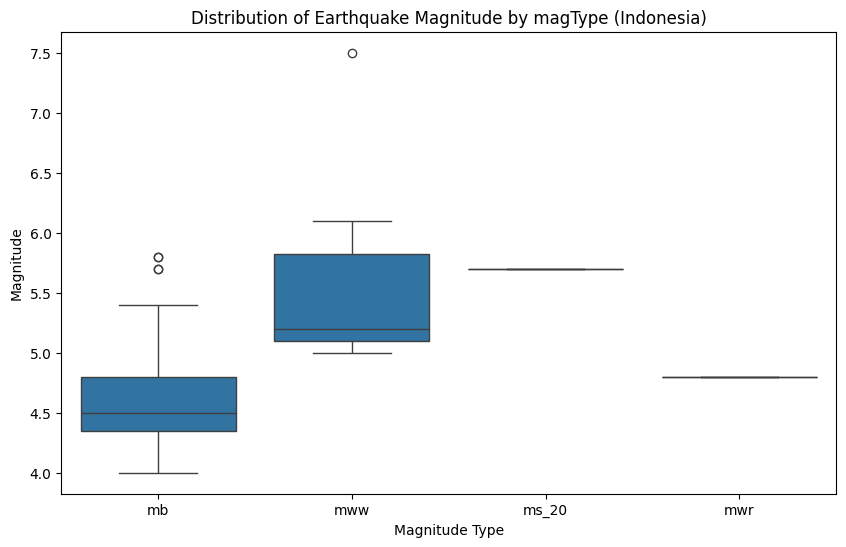

In [4]:
# Load dataset
eqk_df = pd.read_csv("CSV_Files/earthquakes.csv")

# Filter earthquake from Indonesia
indo_eqk = eqk_df[eqk_df['place'].str.contains("Indonesia", na=False)]

# Create Box plot
plt.figure(figsize=(10,6))

sns.boxplot(x='magType', y='mag', data=indo_eqk)

plt.title("Distribution of Earthquake Magnitude by magType (Indonesia)")
plt.xlabel("Magnitude Type")
plt.ylabel("Magnitude")

plt.show()

Here,

**What was done :** The earthquake dataset was filtered to include only records from Indonesia. A box plot was then created to show the distribution of earthquake magnitudes for each magType.

**Why :** Box plots help visualize the spread, median, and outliers of magnitude values for each magnitude type.

**Interpretation :** The plot compares how earthquake magnitudes vary across different magType categories in Indonesia.

## 4.  Weekly High–Low Difference (faang.csv)

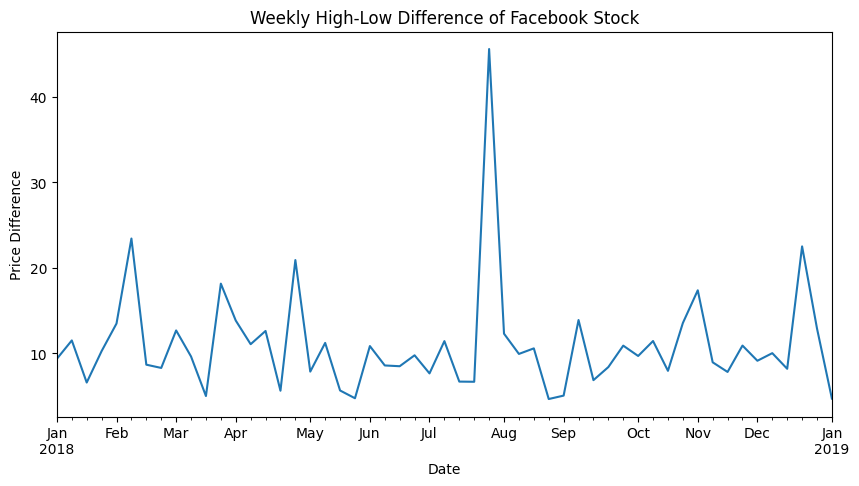

In [5]:
# Convert index to datetime
faang_df.index = pd.to_datetime(faang_df.index)

# Filter only Facebook data
fb = faang_df[faang_df["ticker"] == 'FB']

# Calculate weekly max high and min low from facebook data
weekly = fb.resample('W').agg({
    'high' : 'max',
    'low' : 'min'
})

# Calculate difference
weekly['difference'] = weekly['high'] - weekly['low']

# Plot the difference
weekly['difference'].plot(figsize=(10,5))

plt.title("Weekly High-Low Difference of Facebook Stock")
plt.xlabel('Date')
plt.ylabel('Price Difference')

plt.show()

Here,

**What was done :** The FAANG dataset was filtered to include only Facebook (FB) stock data. Weekly maximum high and minimum low prices were calculated, and the weekly high-low difference was computed and plotted.

**Why :** faang_df["ticker"] == 'FB' was used to filter only Facebook data.
  pd.to_datetime(faang_df.index) was used to convert the index to datetime, which is required for time-based operations.
  .resample('W') was used to group data by week.
  .agg({'high':'max','low':'min'}) was used to calculate weekly high and low efficiently.
  Plotting weekly['difference'] was used to visualize weekly volatility clearly.

**Interpretation :** The plot shows weeks with large price swings as peaks, indicating high volatility, and weeks with smaller differences as valleys, indicating relative stability in Facebook stock prices.

## 5. After-Hours Trading Analysis (faang.csv)

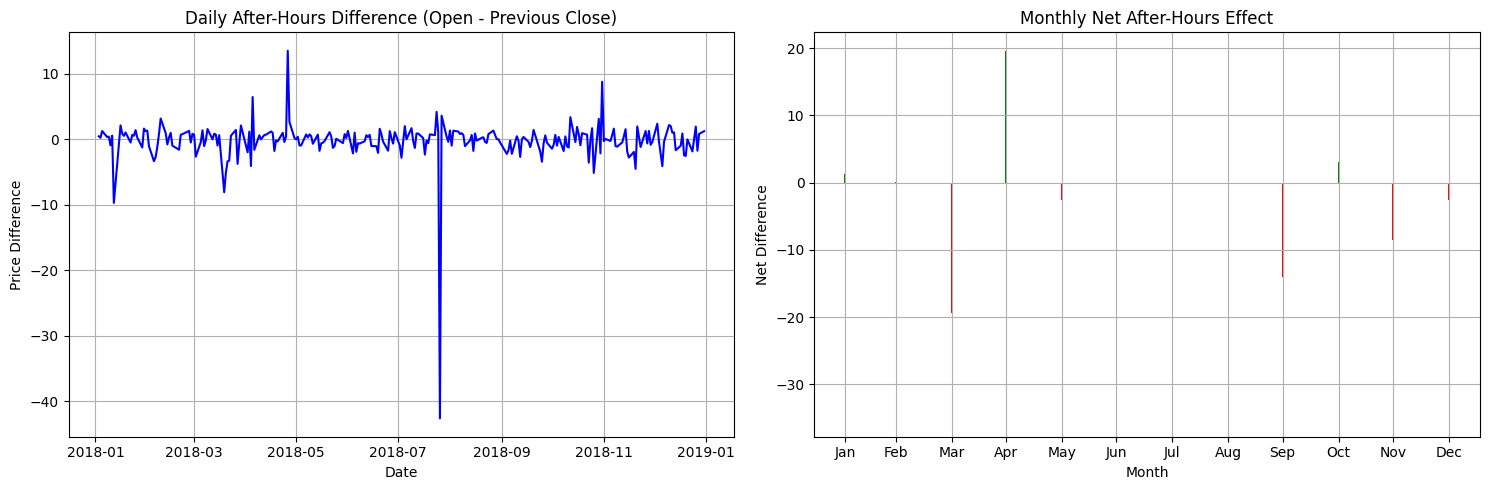

In [6]:
# Filter only Facebook data
fb = faang_df[faang_df["ticker"] == 'FB'].copy()

# Calculate daily after-hours difference: today's open - previous day's close
fb['daily_afterhours_diff'] = fb['open'] - fb['close'].shift(1)

# Resample monthly to get net after-hours effect
monthly_diff = fb['daily_afterhours_diff'].resample('ME').sum()

# Set colors for monthly bars: green for gains, red for losses
colors = ['green' if x>= 0 else 'red' for x in monthly_diff]

# Create side-by-side subplots
fig, axes = plt.subplots(1,2, figsize=(15,5))

# Subplot 1: Daily line plot
axes[0].plot(fb.index, fb['daily_afterhours_diff'], color='blue')
axes[0].set_title("Daily After-Hours Difference (Open - Previous Close)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Price Difference")
axes[0].grid(True)

# Subplot 2: Monthly bar plot
axes[1].bar(monthly_diff.index, monthly_diff, color=colors)
axes[1].set_title("Monthly Net After-Hours Effect")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Net Difference")
axes[1].set_xticks(monthly_diff.index)
axes[1].set_xticklabels([d.strftime('%b') for d in monthly_diff.index])  # three-letter month
axes[1].grid(True)

plt.tight_layout() # Adjust spacing so labels and titles are readable
plt.show()

Here,

**What was done :** The FAANG dataset was filtered to include only Facebook stock. The daily after-hours difference was calculated as today’s open − previous day’s close. Two subplots were created: a line plot showing daily after-hours differences and a bar plot showing the monthly net effect.

**Why :**  fb['close'].shift(1) shifts the closing prices by one day to compute the previous day’s close, which is needed for the after-hours difference.
.copy() ensures that adding new columns does not affect the original DataFrame and avoids warnings.
.resample('ME').sum() aggregates daily differences to monthly totals.
.sum() calculates the total after-hours effect for each month.
axes[1].set_xticks(...) specifies where tick marks appear on the x-axis (positions).
axes[1].set_xticklabels(...) specifies what text labels to show for each x-tick (e.g., 'Jan', 'Feb', 'Mar').

**Interpretation :** The line plot shows daily after-hours volatility.The bar plot shows net monthly gains or losses.Together, they reveal how daily fluctuations accumulate into monthly trends.

# PART - II

## 1.  Correlation Heatmap (earthquakes.csv)

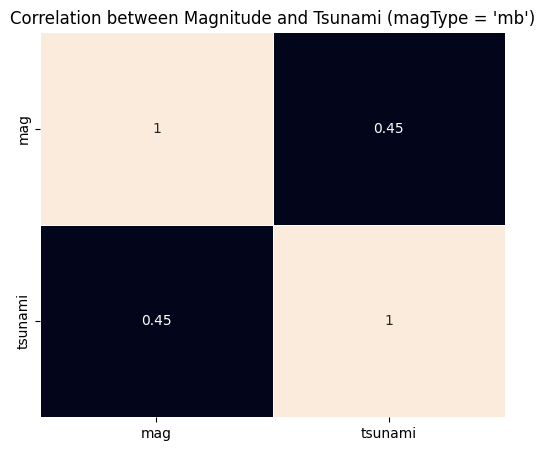

In [7]:
# Load the earthquake dataset
eqkk_df = pd.read_csv("CSV_Files/earthquakes.csv")

# Filter for magType == 'mb'
eqk_mb = eqkk_df[eqkk_df['magType'] == 'mb']

# Select only relevant columns
cols = ['mag', 'tsunami']
eqk_mb_subset = eqk_mb[cols]

# Compute correlation matrix
corr_matrix = eqk_mb_subset.corr()

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True,cbar=False, linewidths=0.5)

plt.title("Correlation between Magnitude and Tsunami (magType = 'mb')")
plt.show()

Here,

**What was done :** The earthquake dataset was filtered to include only records with magType == 'mb'. Only the columns mag (magnitude) and tsunami were selected. A correlation matrix was computed and visualized as a heatmap using seaborn.

**Why :** .corr() calculates the linear correlation between columns.
sns.heatmap() visualizes these correlations clearly, with annot=True to show values and linewidths=0.5 to separate cells.
cbar=False removes the color bar since only the correlation numbers are important.

**Interpretation :** The diagonal shows perfect correlation (1) of each column with itself.The off-diagonal value shows the correlation between magnitude and tsunami occurrence (e.g., 0.45 → positive relationship).

This indicates that stronger earthquakes tend to have a higher chance of causing tsunamis, but the correlation is moderate.

## 2. Tukey Fence Box Plots (faang.csv)

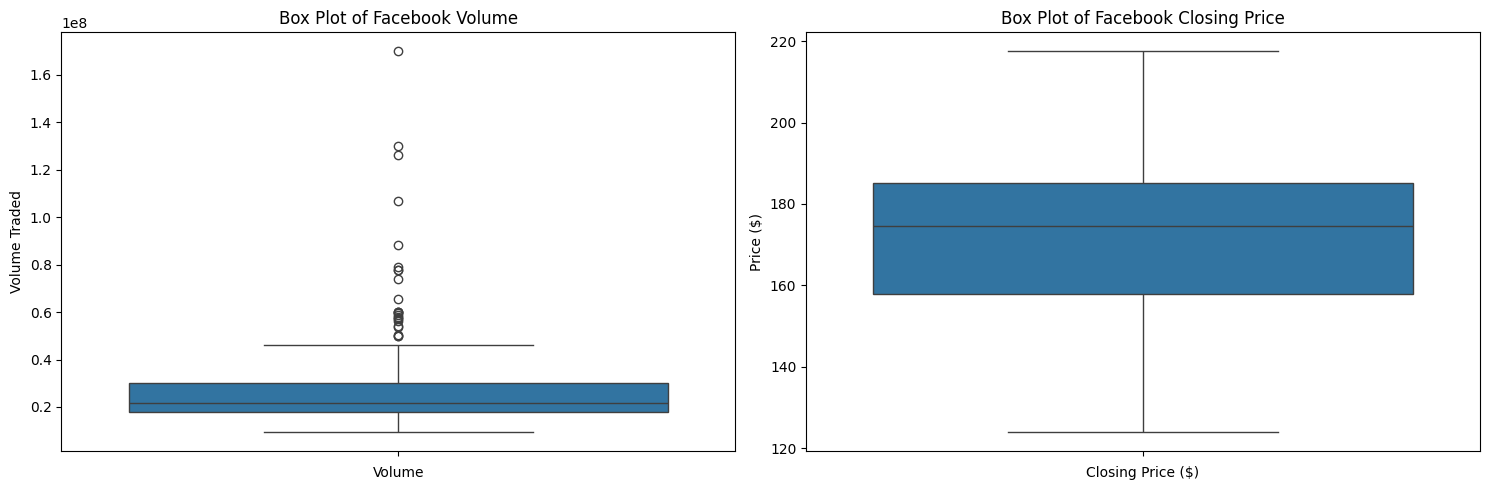

In [8]:
# Filter for Facebook
fb = faang_df[faang_df['ticker'] == 'FB'].copy()

# Create side-by-side box plots
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Box plot for volume
sns.boxplot(y=fb['volume'], ax=axes[0])
axes[0].set_title("Box Plot of Facebook Volume")
axes[0].set_xlabel("Volume") 
axes[0].set_ylabel("Volume Traded")

# Box plot for Closing Price
sns.boxplot(y=fb['close'], ax=axes[1])
axes[1].set_title("Box Plot of Facebook Closing Price")
axes[1].set_xlabel("Closing Price ($)")
axes[1].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()


Here,

**What was done :** The Facebook stock data was filtered from the FAANG dataset. Two box plots were created side by side: one for daily volume traded and another for closing price.

**Why :** Box plots (Tukey Fence) show the spread, median, quartiles, and outliers.
sns.boxplot() is used to easily generate the plots.
plt.subplots() allows the volume and closing price box plots to be displayed side-by-side for easier comparison.

**Interpretation :** The median, interquartile range, and potential outliers for volume and closing price are clearly visible.

## 3.  Tukey fence bounds (faang.csv)

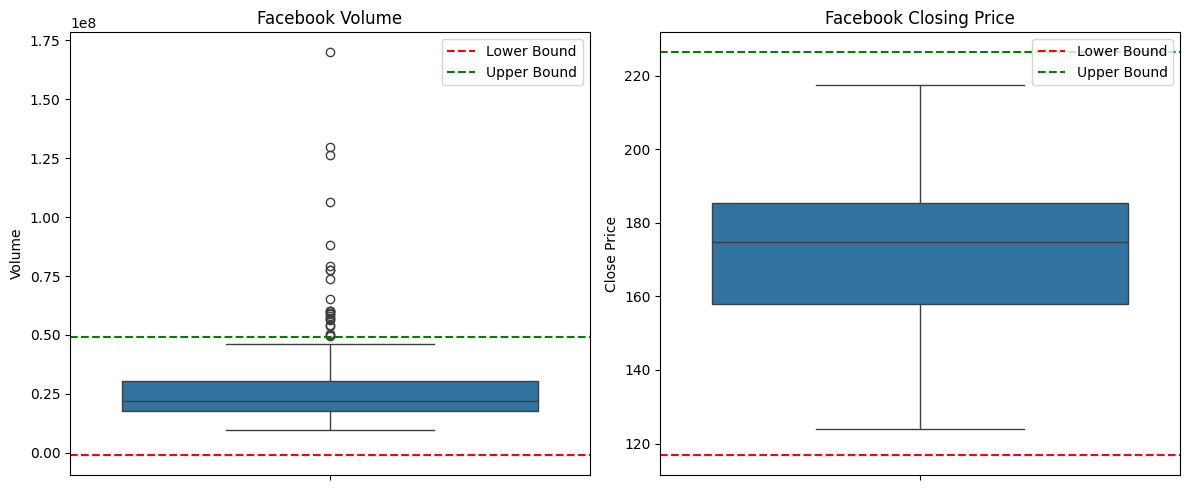

In [9]:
# Create side-by-side box plots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Volume Tukey fence
Q1 = fb['volume'].quantile(0.25)
Q3 = fb['volume'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

sns.boxplot(y=fb['volume'], ax=axes[0])
axes[0].axhline(lower, color='red', linestyle = '--', label='Lower Bound')
axes[0].axhline(upper, color='green', linestyle = '--', label='Upper Bound')
axes[0].set_title("Facebook Volume")
axes[0].set_ylabel("Volume")
axes[0].legend()

# Closing price Tukey fence
Q1 = fb['close'].quantile(0.25)
Q3 = fb['close'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

sns.boxplot(y=fb['close'], ax=axes[1])
axes[1].axhline(lower, color='red', linestyle='--', label='Lower Bound')
axes[1].axhline(upper, color='green', linestyle='--', label='Upper Bound')
axes[1].set_title("Facebook Closing Price")
axes[1].set_ylabel("Close Price")
axes[1].legend()


plt.tight_layout()
plt.show()


Here,

**What was done :** Box plots were created for Facebook’s trading volume and closing price using subplots. The Tukey fence bounds were calculated using Q1 and Q3 obtained from the quantile() method. Reference lines representing the lower bound and upper bound were added to each plot.

**Why :** quantile(0.25) and quantile(0.75) are used to compute Q1 and Q3, which define the middle 50% of the data.
The Interquartile Range (IQR = Q3 − Q1) measures the spread of this middle portion and is used to detect outliers.
The Tukey fence formulas (Q1 − 1.5×IQR and Q3 + 1.5×IQR) help identify values that fall far outside the normal range.
sns.boxplot() visually summarizes the data distribution by showing the median, quartiles, and potential outliers.
axhline() is used to draw horizontal reference lines so the Tukey fence bounds are clearly visible on the plot.
plt.subplots() allows the volume and closing price box plots to be displayed side-by-side for easier comparison.
legend() helps label the lower and upper bound lines so viewers can easily understand the reference limits.

**Interpretation :** Values outside the Tukey fence bounds indicate possible outliers, meaning unusually high or low trading volume or closing prices for Facebook stock.

## 4.   Shaded Tukey Fence Region

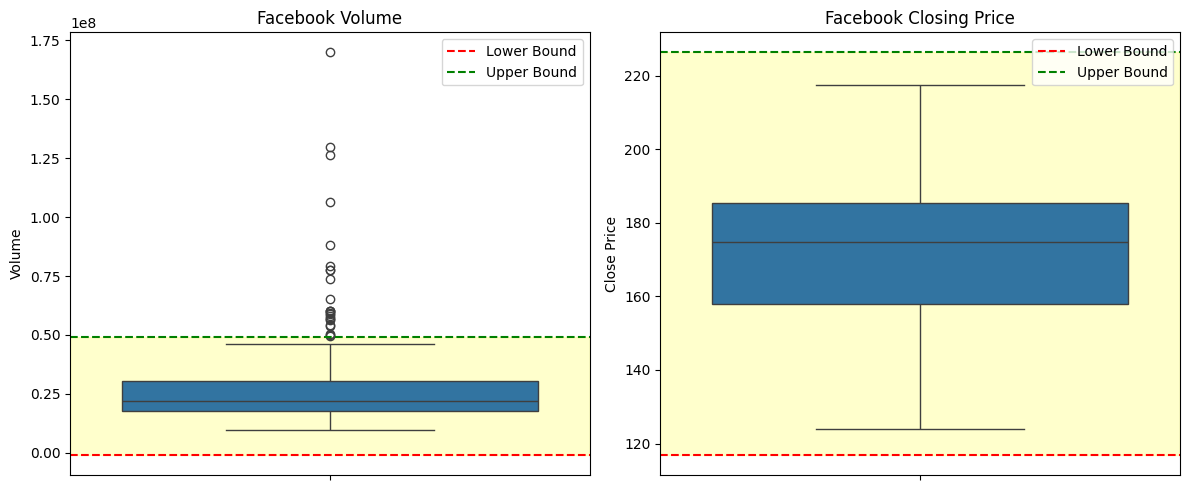

In [10]:
# Create side-by-side box plots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Volume Tukey fence
Q1 = fb['volume'].quantile(0.25)
Q3 = fb['volume'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

sns.boxplot(y=fb['volume'], ax=axes[0])
axes[0].axhline(lower, color='red', linestyle = '--', label='Lower Bound')
axes[0].axhline(upper, color='green', linestyle = '--', label='Upper Bound')

# Shade Tukey region
axes[0].axhspan(lower, upper, color='yellow', alpha=0.2)

axes[0].set_title("Facebook Volume")
axes[0].set_ylabel("Volume")
axes[0].legend()

# Closing price Tukey fence
Q1 = fb['close'].quantile(0.25)
Q3 = fb['close'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

sns.boxplot(y=fb['close'], ax=axes[1])
axes[1].axhline(lower, color='red', linestyle='--', label='Lower Bound')
axes[1].axhline(upper, color='green', linestyle='--', label='Upper Bound')

# Shade Tukey region
axes[1].axhspan(lower, upper, color='yellow', alpha=0.2)

axes[1].set_title("Facebook Closing Price")
axes[1].set_ylabel("Close Price")
axes[1].legend()


plt.tight_layout()
plt.show()



Here,

**What was done :** The Tukey fence bounds were calculated for Facebook’s volume and closing price, as in the previous box plots. The region between the lower and upper bounds was shaded using axhspan() to highlight the normal data range.

**Why :** axhspan(lower, upper, color, alpha) fills the area between the Tukey fence limits, visually showing the expected range. alpha=0.2 makes the color transparent so the box plot is still visible.

**Interpretation :** The shaded region represents the Tukey fence “normal” range.
Any points outside this shaded area are potential outliers in Facebook’s trading volume or closing price.

## 5.  Highlight Price Decline (faang.csv)

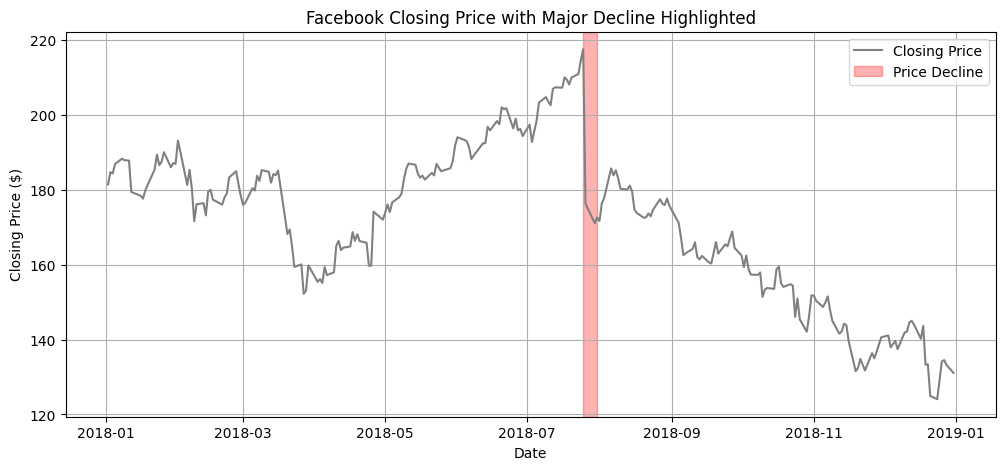

In [11]:
# Line plot of closing price
plt.figure(figsize=(12,5))
plt.plot(fb.index, fb['close'], label="Closing Price", color='gray')

# Highlight period of decline
plt.axvspan('2018-07-25', '2018-07-31', color='red', alpha=0.3, label='Price Decline');

# Titles and labels
plt.title("Facebook Closing Price with Major Decline Highlighted")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")

plt.legend()
plt.grid(True)

plt.show()


Here,

**What was done :** A line plot of Facebook’s closing price was created. The period from July 25, 2018, to July 31, 2018 was highlighted using axvspan() to show the major decline in price.

**Why :** plt.plot() shows the closing price trend over time.
 .axvspan(start, end, color, alpha) shades a vertical region to highlight specific dates of interest.
label and plt.legend() make the highlighted period identifiable.
Grid, titles, and axis labels improve clarity and readability.

**Interpretation :** The shaded red region clearly marks the period of significant price decline.
This visualization helps quickly identify when the decline occurred and its relative duration compared to the rest of the year.

## 6.  Event Annotations (faang.csv)

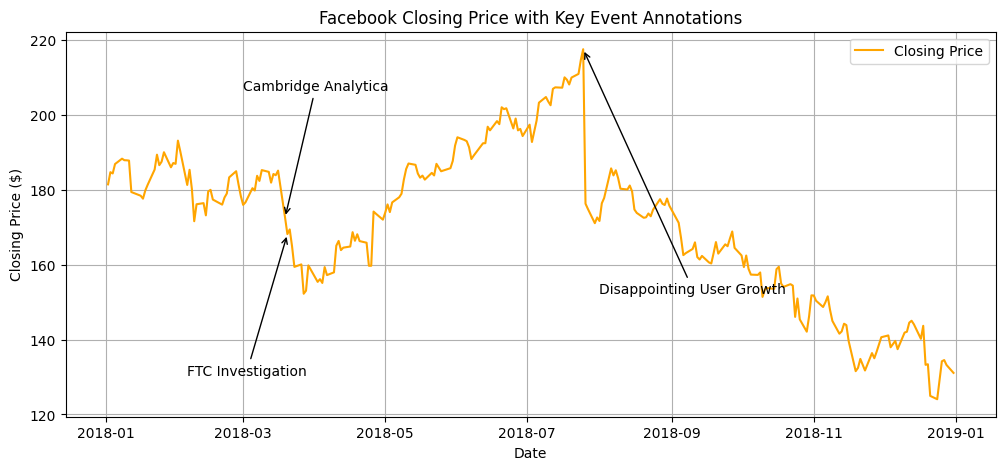

In [12]:
# Line plot of closing price
plt.figure(figsize=(12,5))
plt.plot(fb.index, fb['close'], label="Closing Price", color='orange')

# Convert strings to Timestamps for annotation and shading
event1 = pd.Timestamp('2018-03-19')
event2 = pd.Timestamp('2018-03-20')
event3 = pd.Timestamp('2018-07-25')

# Annotate events
plt.annotate(
    'Cambridge Analytica', 
    xy=(event1, fb.loc[event1,'close']),
    xytext=(pd.Timestamp('2018-03-01'), fb['close'].max()*0.95),
     arrowprops=dict(arrowstyle='->')
     )

plt.annotate(
    'FTC Investigation', 
    xy=(event2, fb.loc[event2,'close']),
    xytext=(pd.Timestamp('2018-02-05'), fb['close'].max()*0.6),
    arrowprops=dict(arrowstyle='->')
    )

plt.annotate(
    'Disappointing User Growth',
    xy=(event3, fb.loc[event3,'close']),
    xytext=(pd.Timestamp('2018-08-01'),fb['close'].max()*0.7),
    arrowprops=dict(arrowstyle='->')
    )

# Titles and labels
plt.title("Facebook Closing Price with Key Event Annotations")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()
plt.grid(True)
plt.show()

Here,

**What was done :** A line plot of Facebook’s closing price was created. Key events — Cambridge Analytica story (Mar 19, 2018), FTC investigation (Mar 20, 2018), and Disappointing user growth (Jul 25, 2018) — were annotated using plt.annotate() with arrows pointing to the relevant dates.

**Why :** plt.plot() shows the trend of closing prices over time.
pd.Timestamp() converts string dates to datetime objects compatible with the plot’s index.
plt.annotate() adds text labels and arrows to highlight important events without cluttering the plot.
xy specifies the point to annotate, while xytext positions the text for readability.
arrowprops visually connects the annotation to the data point.

**Interpretation :** The annotations highlight how major events correspond to changes in closing price.This visualization helps quickly identify the timing and impact of key events on Facebook’s stock.

## 7. Colormap Customization

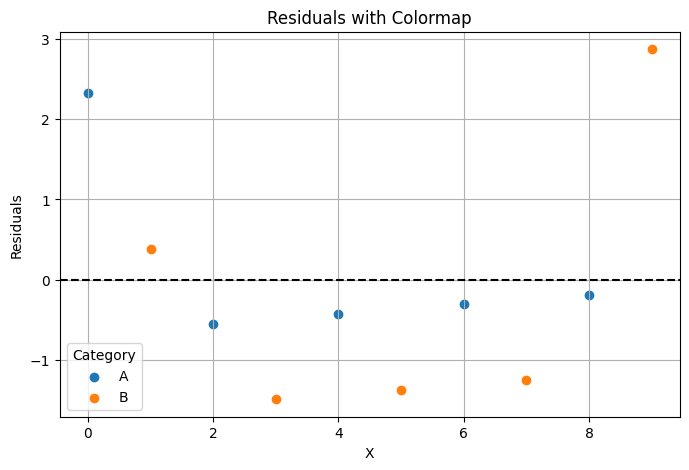

In [13]:
# Plot residuals of y vs x, optionally coloring by category.
"""  Parameters:
    - x: independent variable
    - y: dependent variable
    - categories: optional categorical variable for color coding
"""
def reg_resid_plots(x, y, categories=None):
    residuals = y - np.poly1d(np.polyfit(x,y,1))(x)
    plt.figure(figsize=(8,5))
    
    if categories is None:
        plt.scatter(x, residuals, color='blue')  # Single color
        
    else: 
        # Use a colormap
        cmap = plt.get_cmap('tab10')
        unique_category = np.unique(categories)
        
        for i, cat in enumerate(unique_category):
            mask = categories == cat
            plt.scatter(x[mask], residuals[mask], color=cmap(i), label=str(cat))
        
        plt.legend(title="Category")
        
    plt.axhline(0, color='black', linestyle='--')
    plt.xlabel("X")
    plt.ylabel("Residuals")
    plt.title("Residuals with Colormap")
    plt.grid(True)
    plt.show()    

# Example Usage
x = np.arange(10)
y = np.array([2, 3, 5, 7, 11, 13, 17, 19, 23, 29])
categories = np.array(['A', 'B', 'A', 'B', 'A', 'B', 'A', 'B', 'A', 'B'])

reg_resid_plots(x, y, categories)
    

Here,

**What was done :** The reg_resid_plots() function plots residuals of y vs x after fitting a simple linear model.
-  If a categories array is provided, each category is plotted in a distinct color using the tab10 colormap.
- A horizontal reference line at 0 is added to show positive vs negative residuals.

**Why :** Because:
- np.polyfit(x, y, 1) computes the best-fit line (slope and intercept) for the data.
 Needed to calculate residuals: the difference between actual and predicted values.
- np.poly1d() converts the slope and intercept from polyfit into a polynomial function for evaluation. Used to compute predicted y-values for residual calculation.
- np.unique(categories) finds all unique categories in the categorical array.
Helps assign a distinct color to each category.
- plt.figure(figsize=(8,5)) creates a new figure of a specified size.
- plt.scatter(x, residuals, color=..., label=...) plots points on the graph.
 color assigns colors from the colormap.
 label is used to create a legend for categories.
- plt.get_cmap('tab10') retrieves a qualitative colormap suitable for categorical comparisons. Ensures colors are distinct and visually clear for each category.
- plt.legend(title="Category") adds a legend to identify which color represents which category.
- plt.axhline(0, color='black', linestyle='--') draws a horizontal reference line at 0. Makes it easy to see positive vs negative residuals.
- plt.xlabel("X") / plt.ylabel("Residuals") / plt.title("Residuals with Colormap")  add axis labels and title. Makes the plot interpretable.
- plt.grid(True) adds a grid for better readability of the residuals along the axes.
- plt.show() renders the plot.

**Interpretation :** Points above 0 indicate y values higher than predicted, and points below 0 are lower than predicted.
Coloring by category lets us compare residual patterns across different groups, helping identify trends, clusters, or outliers.